In [4]:
data_folder="../Data/" #and libraries and funcitons
import sys
import numpy as np
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import tqdm


sys.path.append(os.path.abspath("../Codes"))

sys.path.append(os.path.abspath("../_Deep_Learning"))

from Utils import split_create_windows, scale_newax
from Utils import freq_filter, windowize,  RegionWiseStandardizer

from BCI_Library import read_subject, saveresults_pickle, compute_welch
from BCI_Library import  train_single_model,select_regions_Cohen_effect_size, build_compiled_mlp

import tensorflow.keras as keras

def compute_power_spectra(data_2_MI, data_2_Rest):
    sfreq = 250
    miff = [8,12]
    maff = [12,30]

    WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                        kargs_welch={"fmin":miff[0], "fmax":maff[-1]})

    return WMI, WRe


def selezione_cohen(WRe, WMI, train_idx, num_best_ROIs):
    training_index_Re = train_idx[np.where(train_idx<len(WRe))] 
    training_index_MI = train_idx[np.where(train_idx>=len(WRe))]-len(WRe)

    regions_selected, effect_size  = select_regions_Cohen_effect_size(wpsdMI=WMI[training_index_MI], 
                                                    wpsdRest=WRe[training_index_Re], 
                                                        important_regions=[], nbest_regions=num_best_ROIs)
    return regions_selected

In [5]:
# Investigate performaces per time
#del train_single_model_investigate2
def train_single_model_investigate2(X_train, X_val, y_train, y_val, method, 
                scaler=StandardScaler, seed=224, return_predictions=True,
                verbose=False, fit_kwargs={}, n_windows=1):
    
    # StandardScaler:
    if scaler is not None:
        scaler_instance = scaler()
        X_train_scaled = scaler_instance.fit_transform(X_train)
        X_val_scaled   = scaler_instance.transform(X_val)

    # Model instance
    try:
        model = method(random_state=seed)
    except:
        try:
            model = method()
        except:
            model = method
    is_keras_model = isinstance(model, tf.keras.Model)

    if is_keras_model:
        model.fit(X_train_scaled, y_train,validation_data=(X_val_scaled, y_val), **fit_kwargs)
    else:
        model.fit(X_train_scaled, y_train)
    acc = {}
    confusion_mat = {}
    labels_preds = {}
    for _ in range(n_windows):
        y_pred = model.predict(X_val_scaled[_::n_windows])
        labels_preds["win_"+str(_)] = {"y_true":y_val[_::n_windows], "y_pred":y_pred}
    
        if is_keras_model:
            y_pred = (y_pred > 0.5).astype(int).ravel()

        # Accuracy   # Confusion matrix
        acc["win_"+str(_)] = accuracy_score(y_val[_::n_windows], y_pred)
        confusion_mat["win_"+str(_)] = confusion_matrix(y_val[_::n_windows], y_pred)
        #print(len(y_val[_::n_windows]))
    if return_predictions:
        return acc, confusion_mat, model, labels_preds
    return acc, confusion_mat, model

def train_single_model_investigate(data_features, labels, train_idx, val_idx, method, 
                scaler=StandardScaler, seed=224, return_predictions=True,
                verbose=False, fit_kwargs={}, n_windows=1):
    
    X_train, X_val = data_features[train_idx], data_features[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]
    
    # StandardScaler:
    if scaler is not None:
        scaler_instance = scaler()
        X_train_scaled = scaler_instance.fit_transform(X_train)
        X_val_scaled   = scaler_instance.transform(X_val)

    # Model instance
    try:
        model = method(random_state=seed)
    except:
        try:
            model = method()
        except:
            model = method
    is_keras_model = isinstance(model, tf.keras.Model)

    if is_keras_model:
        model.fit(X_train_scaled, y_train,validation_data=(X_val_scaled, y_val), **fit_kwargs)
    else:
        model.fit(X_train_scaled, y_train)
    acc = {}
    confusion_mat = {}
    labels_preds = {}
    for _ in range(n_windows):
        y_pred = model.predict(X_val_scaled[_::n_windows])
        labels_preds["win_"+str(_)] = {"y_true":y_val[_::n_windows], "y_pred":y_pred}
    
        if is_keras_model:
            y_pred = (y_pred > 0.5).astype(int).ravel()

        # Accuracy   # Confusion matrix
        acc["win_"+str(_)] = accuracy_score(y_val[_::n_windows], y_pred)
        confusion_mat["win_"+str(_)] = confusion_matrix(y_val[_::n_windows], y_pred)
        #print(len(y_val[_::n_windows]))
    if return_predictions:
        return acc, confusion_mat, model, labels_preds
    return acc, confusion_mat, model

# Region Agnostic - test on same subject - PowerSpectra - Perf across Time 

## Per fold region selection

In [27]:
import re
import pickle

Addestramento = "Encoder_timeseries_Decoder_spectra_log_simpleNormalization_EEG_MEG"
pattern = re.compile(r"^\d{4}-\d{2}-\d{2}-\d{2}_\d{2}_\d{2}_" + re.escape(Addestramento) + r"$")

DataType = "EEG+MEG"
CNN_o_Autoencoder = "Autoencoder" # Autoencoder, # CNN, #SupervisedAutoencoder

# TODO change save results, trova modo per farlo
saveresults = False
region_specific = False

sfreq = 250
seed = 224
Features_name = CNN_o_Autoencoder + "_extracted"
Region_Selection= "Cohen's d effect size selection" # "-"
PFR = True
random_seed=224

Classifier_names, meths = ["SVC"],[SVC]  #["LDA", "SVC", "RandomForest"],[LDA, SVC, RandomForestClassifier] # ["MLP"], ["MLP"]
MLP_fit_kwargs={'epochs':20, 'batch_size':32}



# Tutti_soggetti = [0]
for Tutti_soggetti in tqdm.tqdm([[i] for i in range(20)]):
    fold_accuracies     = []
    all_predictions     = []
    confusions_matrices = []

    model_path_1 = f"../_Deep_Learning/Models_trained/Subject_"
    # model path 2 = f"{subject_index}/"
    # model path 2.5 = f"{DataType}/"
    model_path_3 = f"{CNN_o_Autoencoder}" + ("s/" if CNN_o_Autoencoder=="Autoencoder" else "/")

    mm = model_path_1 + f"{Tutti_soggetti[0]}/" + f"{DataType}/" + model_path_3
    matching_addestramenti = [f for f in os.listdir(mm) if pattern.match(f)]
    
    if len(matching_addestramenti) != 1:
        raise Exception(f"Ho trovato {len(matching_addestramenti)} addestramenti corrispondenti a {Addestramento} per il soggetto {donor_subject}.", 
                        "Controlla bene se è quello che vuoi o se c'è un errore nei nomi delle cartelle.")
    model_path_4 = matching_addestramenti[0] + "/"

    lib_path = model_path_1 + f"{Tutti_soggetti[0]}/" + f"{DataType}/" + model_path_3 + model_path_4
    sys.path.append(os.path.abspath(lib_path))
    try:
        del MultiTaskModel_PowerSpectra
        print("ho resettato MultiTaskModel")
    except:
        print("non ho resettato MultiTaskModel")

    try :
        from _Backup_Library import MultiTaskModel_PowerSpectra
    except:
        from Deep_Library_BCI import MultiTaskModel_PowerSpectra
        raise Exception("Non ho caricato dal backup, controlla bene se è quello che vuoi")

    use_GRU = True if "GRU" in model_path_4.replace("/","").split("_") else False

    if CNN_o_Autoencoder == "CNN":
        model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=True, use_decoder=False, use_GRU=use_GRU, build_convolutional_decoder = True, EEG_concat_MEG = True)
    if CNN_o_Autoencoder == "Autoencoder":
        model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=False, use_decoder=True, use_GRU=use_GRU, build_convolutional_decoder = True, EEG_concat_MEG = True)
    if CNN_o_Autoencoder == "SupervisedAutoencoder":
        try:
            model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=True, use_decoder=True, use_GRU=use_GRU, build_convolutional_decoder = True, EEG_concat_MEG = True)
        except:
            model = MultiTaskModel_PowerSpectra(input_shape=(256,2), output_shape=24, use_classifier=True, use_decoder=True, build_convolutional_decoder = True, EEG_concat_MEG = True)


    model.build(input_shape=(256,2))

    today = date.today()

    n_folds=5
    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

    start_val_test = 1           # seconds where to start to extract windows
    sampling_hz = 250;  start_val_test = start_val_test*sampling_hz
    input_shape = 256   # length of each window
    shift = 85          # points to shift for next window in data
    num_windows_val_test = 12    # how many windows to extract from each trial
    end_val_test = start_val_test + (num_windows_val_test-1)*shift + input_shape  # seconds where to end to extract windows (1500 == 6 seconds)

    start_train = 3           # seconds where to start to extract windows
    start_train = start_train*sampling_hz
    num_windows_train = 7     # how many windows to extract from each trial
    end_train = start_train + (num_windows_train-1)*shift + input_shape  # seconds where to end to extract windows (1500 == 6 seconds)

    num_best_ROIs = 8


    verbose = False


    for Classifier_name, meth in zip(Classifier_names,meths):
        
        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Accuracy": [],
            "Features": [],
            "Comments": [],
            "Region Selection": [],
            "Date": []
        })
        if rl is None: rl = Rows
    
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)

        subject_index = Tutti_soggetti[0]

        model_path = model_path_1 + f"{subject_index}/" + f"{DataType}/" + model_path_3 + model_path_4
        Comments = model_path_4[:-1]+ f" Subject addestramento {subject_index}"

        data_2_Rest_EEG = read_subject(data_folder, "EEG", "Baseline",subject_index,verbose=verbose)
        data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index,verbose=verbose)
        data_EEG = np.concatenate((data_2_Rest_EEG, data_2_MI_EEG), axis=0)
        WMI_EEG, WRe_EEG = compute_power_spectra(data_2_MI_EEG,data_2_Rest_EEG)
        data_EEG = freq_filter(data_EEG, sf=250, freqs=[4,45], type_filter="bandpass") # axis = -1 by default
        
        data_2_Rest_MEG = read_subject(data_folder, "MEG", "Baseline",subject_index,verbose=verbose)
        data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index,verbose=verbose)
        data_MEG = np.concatenate((data_2_Rest_MEG, data_2_MI_MEG), axis=0)
        WMI_MEG, WRe_MEG = compute_power_spectra(data_2_MI_MEG,data_2_Rest_MEG)
        data_MEG = freq_filter(data_MEG, sf=250, freqs=[4,45], type_filter="bandpass") # axis = -1 by default
        

        # y shape: (n_trials,) with negative values for Rest and positive for MI
        y_EEG = np.concatenate([-np.ones((data_2_Rest_EEG.shape[0])), np.ones((data_2_MI_EEG.shape[0]))])
        y_MEG = np.concatenate([-np.ones((data_2_Rest_MEG.shape[0])), np.ones((data_2_MI_MEG.shape[0]))])

        assert np.array_equal(y_EEG, y_MEG), "Le etichette di EEG e MEG non corrispondono. Controlla i dati."
        
        
        tutti_fold_selezioni_regioni = []
        for fold_idx, (train_idx, block_idx) in enumerate(kf.split(data_EEG, y_EEG)):
        ########################## DATA PREPROCESSING ##########################################
            Feat_train_regions_selected = None  #np.empty((len(train_idx)*11,0))
            Feat_test_regions_selected = None # np.empty()
            
            # Scelta di regioni: scelgo tutte le regioni tra EEG e MEG
            regions_selected_EEG = selezione_cohen(WRe_EEG, WMI_EEG, train_idx, num_best_ROIs)
            regions_selected_MEG = selezione_cohen(WRe_MEG, WMI_MEG, train_idx, num_best_ROIs)
            regions_selected = list(set(regions_selected_EEG) | set(regions_selected_MEG))
            


            regions_selected.sort()
            print("\n Per il fold ", fold_idx, " Ho selezionato un numero di regioni pari a ", len(regions_selected), regions_selected)
            tutti_fold_selezioni_regioni.append(regions_selected)
            
            for region_index, regione in enumerate(regions_selected):
            
                split_num = fold_idx+1
                if region_specific:
                    model.load_weights(model_path+f"Split_{split_num}/Region_{regione}/model.weights.h5")
                else:
                    model.load_weights(model_path+f"Split_{split_num}/model.weights.h5")

                x_train_MEG, y_train_MEG, x_val_MEG, y_val_MEG, x_test_MEG, y_test_MEG = (
                split_create_windows(data_MEG, y_MEG, train_idx, block_idx, 1, win_len=input_shape, shift=shift,
                    random_seed=random_seed, regione=regione,
                    start_train=start_train, end_train=end_train,
                    start_val_test=start_val_test, end_val_test=end_val_test)
                    )

                x_train_MEG, x_val_MEG, x_test_MEG = scale_newax (x_train_MEG, y_train_MEG, x_val_MEG, y_val_MEG, x_test_MEG, y_test_MEG, scaler=RegionWiseStandardizer())

                x_train_EEG, y_train_EEG, x_val_EEG, y_val_EEG, x_test_EEG, y_test_EEG = (
                split_create_windows(data_EEG, y_EEG, train_idx, block_idx, 1, win_len=input_shape, shift=shift,
                    random_seed=random_seed, regione=regione,
                    start_train=start_train, end_train=end_train,
                    start_val_test=start_val_test, end_val_test=end_val_test)
                    )
                assert np.array_equal(y_train_EEG, y_train_MEG), "Le etichette di train EEG e MEG non corrispondono. Controlla i dati."
                assert np.array_equal(y_val_EEG, y_val_MEG), "Le etichette di val EEG e MEG non corrispondono. Controlla i dati."
                assert np.array_equal(y_test_EEG, y_test_MEG), "Le etichette di test EEG e MEG non corrispondono. Controlla i dati."
                x_train_EEG, x_val_EEG, x_test_EEG = scale_newax (x_train_EEG, y_train_EEG, x_val_EEG, y_val_EEG, x_test_EEG, y_test_EEG, scaler=RegionWiseStandardizer())

            
                # TODO unito EEG e MEG per train, val e test
                x_train = np.concatenate((x_train_EEG, x_train_MEG), axis=-1)  # shape (n_windows, timepoints, 2)
                x_test = np.concatenate((x_test_EEG, x_test_MEG), axis=-1)  # shape (n_windows, timepoints, 2)


                Features_training_1_regione = model.encoder(x_train)
                Features_test_1_regione = model.encoder(x_test)
                # Features_training_1_regione  shape (n_windows,16)
                
                
                ################################### Feature Extractions ##########################################
                if Feat_train_regions_selected is None:
                    Feat_train_regions_selected = np.empty((Features_training_1_regione.shape[0],0))
                    Feat_test_regions_selected = np.empty((Features_test_1_regione.shape[0],0))

                Feat_train_regions_selected = np.concatenate((Feat_train_regions_selected,tf.reshape(Features_training_1_regione, (Features_training_1_regione.shape[0], -1))),axis = 1) # asse di regione
                Feat_test_regions_selected = np.concatenate((Feat_test_regions_selected,tf.reshape(Features_test_1_regione, (Features_test_1_regione.shape[0], -1))),axis = 1) # asse di regione


    

            if Classifier_name.lower()=="mlp":
                    meth = build_compiled_mlp(input_dim=Feat_train_regions_selected.shape[1])
                    
            acc, cm, model_classifier,predictions = train_single_model_investigate2(Feat_train_regions_selected, Feat_test_regions_selected,
                                                (y_train_EEG > 0).astype(int), (y_test_EEG > 0).astype(int), return_predictions=True,
                                                method=meth, seed=224, fit_kwargs=MLP_fit_kwargs,
                                                n_windows = num_windows_val_test)
            fold_accuracies.append(acc)
            all_predictions.append(predictions)
            confusions_matrices.append(cm)
            
            if verbose:
                print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                print(cm)

            #####################################################################################################################

        new_row = {
            "ROIs": [regions_selected],
            "NROIs":[len(regions_selected)],
            "DataType": [DataType],
            "subject": [subject_index],
            "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
            "Features": [Features_name],
            "Comments": [Comments],
            "Region Selection": [Region_Selection],
            "Date": [today],

        }

        with open(f"../Results/BCI_Performances/DNN/Across_time/Performances_DNN_across_time_subject_{subject_index}.pkl", "wb") as f:
            pickle.dump({
                "Details": new_row,
                "Selected_regions_per_fold_EEG_U_MEG": tutti_fold_selezioni_regioni,
                "all_predictions": all_predictions,
                "fold_accuracies": fold_accuracies
                        }, f)

  0%|          | 0/20 [00:00<?, ?it/s]

ho resettato MultiTaskModel


##############################
 EEG+MEG SVC

 Per il fold  0  Ho selezionato un numero di regioni pari a  14 [6, 7, 8, 14, 15, 17, 22, 23, 25, 27, 32, 43, 46, 58]

 Per il fold  1  Ho selezionato un numero di regioni pari a  14 [6, 7, 8, 14, 15, 17, 22, 23, 25, 27, 42, 43, 50, 58]

 Per il fold  2  Ho selezionato un numero di regioni pari a  14 [8, 14, 15, 16, 17, 21, 22, 23, 25, 26, 27, 42, 43, 61]

 Per il fold  3  Ho selezionato un numero di regioni pari a  13 [6, 14, 15, 17, 22, 23, 25, 27, 42, 43, 50, 51, 58]

 Per il fold  4  Ho selezionato un numero di regioni pari a  12 [6, 8, 14, 15, 22, 23, 27, 42, 43, 50, 51, 58]


  5%|▌         | 1/20 [00:23<07:30, 23.71s/it]

ho resettato MultiTaskModel


##############################
 EEG+MEG SVC

 Per il fold  0  Ho selezionato un numero di regioni pari a  14 [1, 6, 7, 14, 19, 23, 32, 42, 43, 50, 51, 59, 61, 67]

 Per il fold  1  Ho selezionato un numero di regioni pari a  15 [1, 6, 7, 14, 19, 23, 26, 31, 32, 42, 43, 50, 59, 61, 67]

 Per il fold  2  Ho selezionato un numero di regioni pari a  13 [1, 6, 7, 14, 19, 23, 42, 43, 50, 51, 59, 61, 67]

 Per il fold  3  Ho selezionato un numero di regioni pari a  14 [1, 6, 7, 14, 17, 22, 23, 42, 43, 50, 51, 59, 61, 67]

 Per il fold  4  Ho selezionato un numero di regioni pari a  12 [1, 6, 7, 14, 23, 26, 43, 50, 51, 59, 61, 67]


 10%|█         | 2/20 [00:52<07:59, 26.63s/it]

...

 90%|█████████ | 18/20 [08:18<00:56, 28.14s/it]

ho resettato MultiTaskModel


##############################
 EEG+MEG SVC

 Per il fold  0  Ho selezionato un numero di regioni pari a  16 [2, 3, 8, 9, 24, 25, 33, 44, 45, 46, 48, 49, 60, 61, 64, 65]

 Per il fold  1  Ho selezionato un numero di regioni pari a  15 [2, 3, 21, 24, 25, 32, 33, 39, 44, 45, 46, 48, 49, 60, 61]

 Per il fold  2  Ho selezionato un numero di regioni pari a  16 [2, 8, 18, 19, 24, 29, 32, 33, 44, 46, 48, 49, 52, 60, 61, 62]

 Per il fold  3  Ho selezionato un numero di regioni pari a  16 [2, 3, 8, 12, 21, 33, 36, 44, 45, 46, 48, 49, 53, 60, 64, 65]

 Per il fold  4  Ho selezionato un numero di regioni pari a  16 [2, 3, 8, 9, 12, 18, 19, 25, 33, 39, 44, 46, 48, 60, 61, 65]


 95%|█████████▌| 19/20 [08:46<00:28, 28.12s/it]

ho resettato MultiTaskModel


##############################
 EEG+MEG SVC

 Per il fold  0  Ho selezionato un numero di regioni pari a  13 [4, 5, 32, 33, 44, 45, 46, 48, 49, 59, 62, 63, 66]

 Per il fold  1  Ho selezionato un numero di regioni pari a  12 [4, 5, 32, 33, 44, 45, 46, 48, 49, 59, 62, 63]

 Per il fold  2  Ho selezionato un numero di regioni pari a  14 [4, 21, 32, 33, 44, 45, 46, 47, 48, 51, 59, 62, 63, 66]

 Per il fold  3  Ho selezionato un numero di regioni pari a  13 [4, 32, 33, 44, 45, 46, 47, 48, 49, 59, 62, 63, 66]

 Per il fold  4  Ho selezionato un numero di regioni pari a  14 [4, 5, 32, 33, 40, 44, 45, 46, 47, 48, 51, 62, 63, 66]


100%|██████████| 20/20 [09:14<00:00, 27.75s/it]


# Investigate 
based on runs of previous section

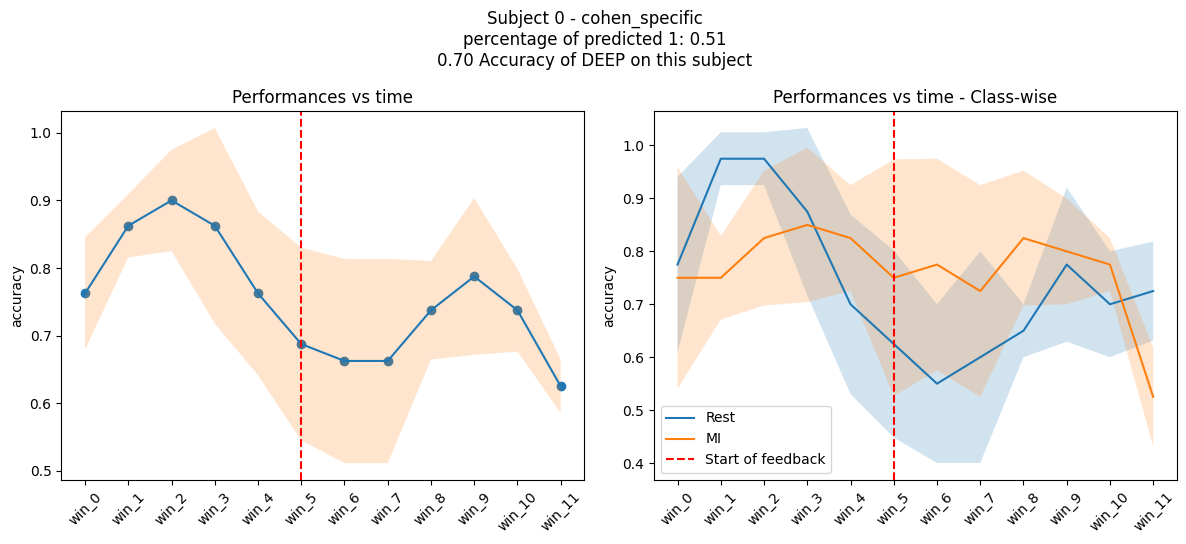

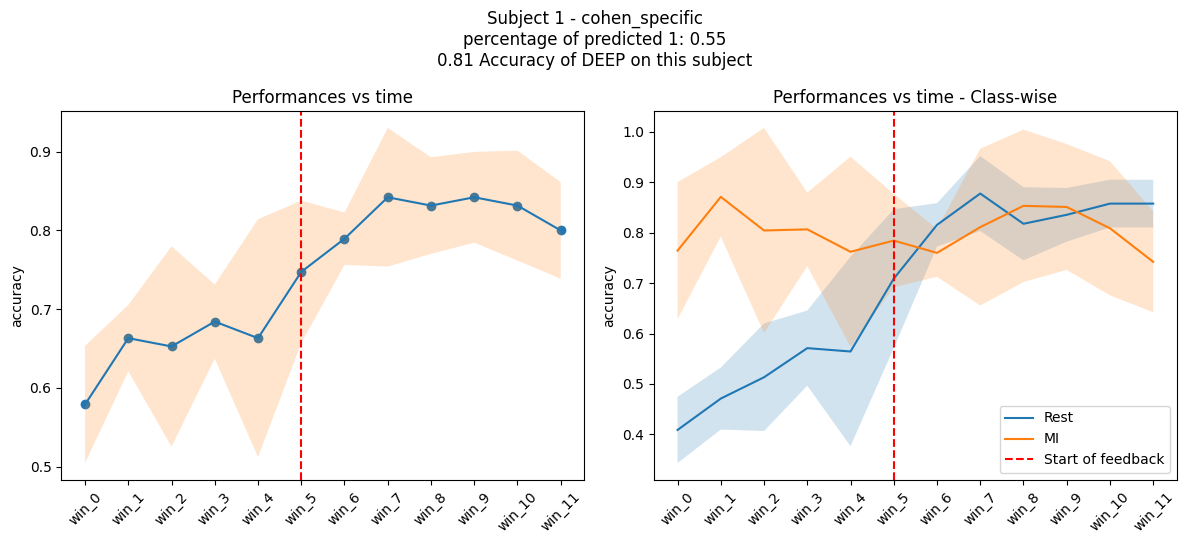

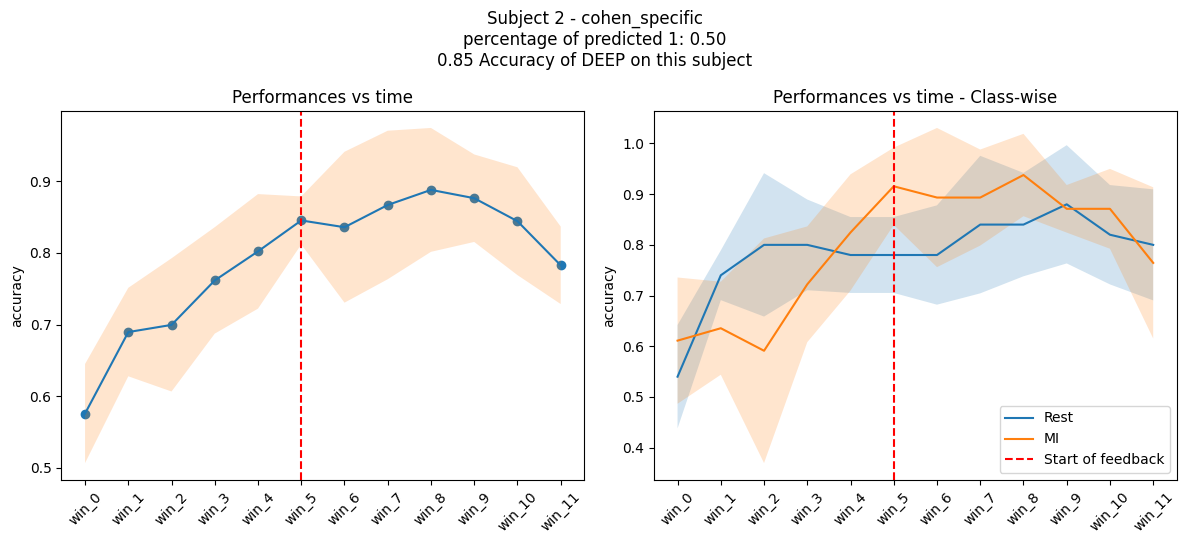

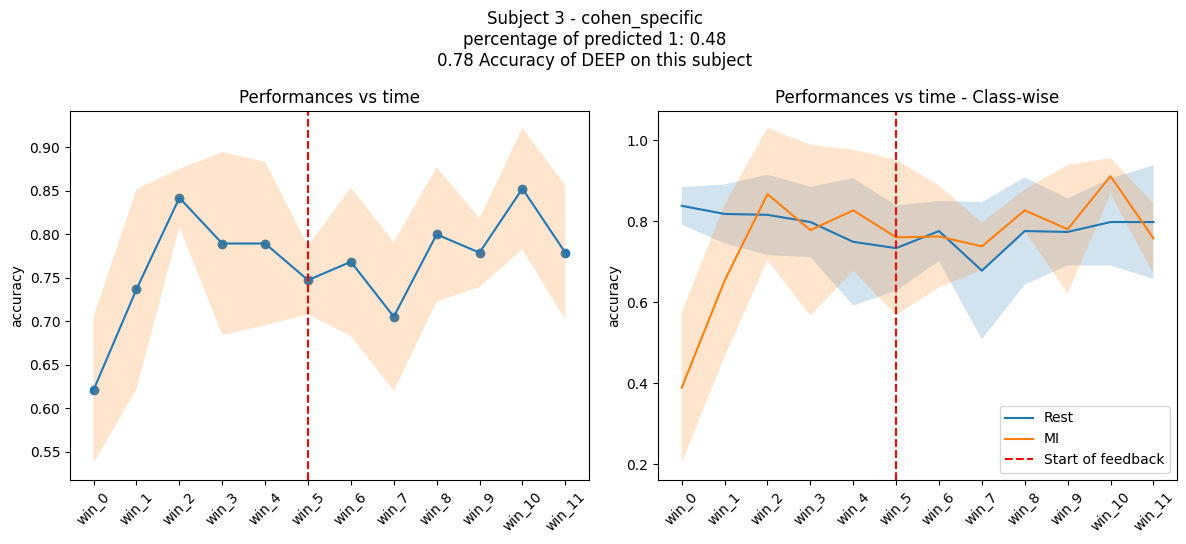

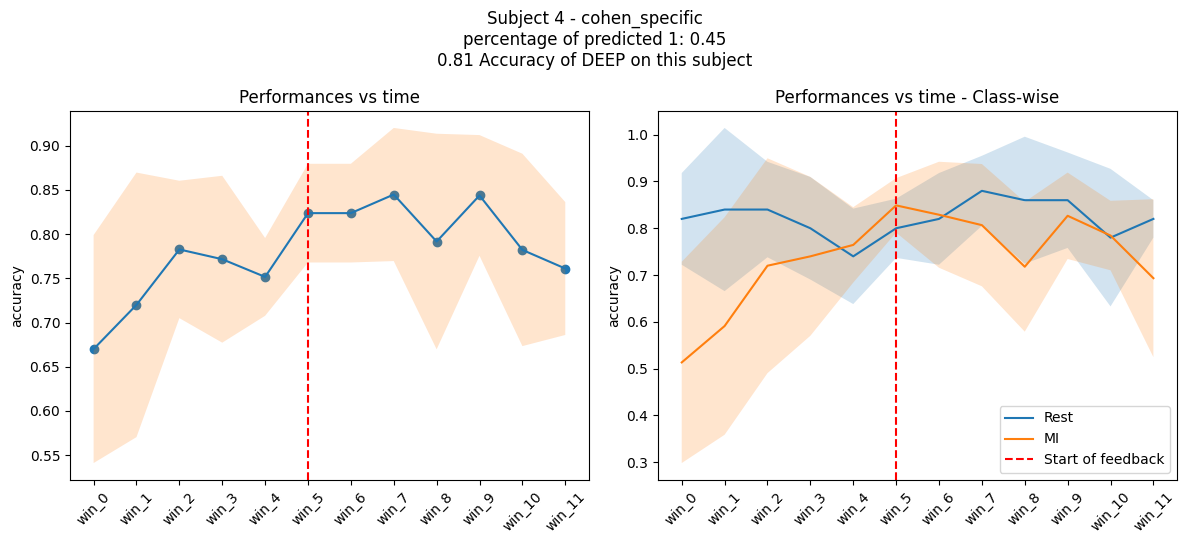

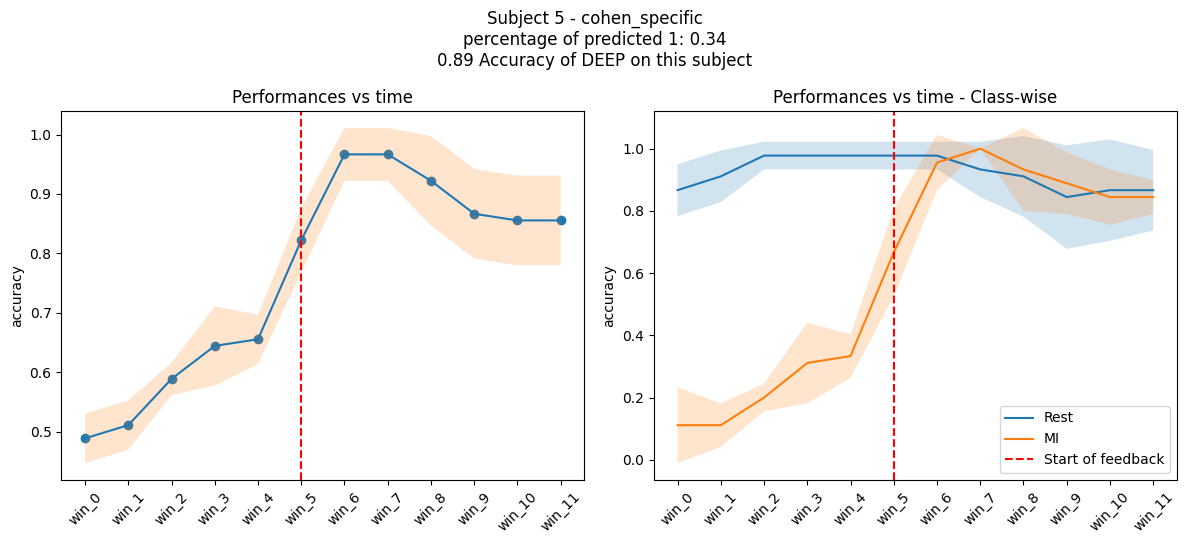

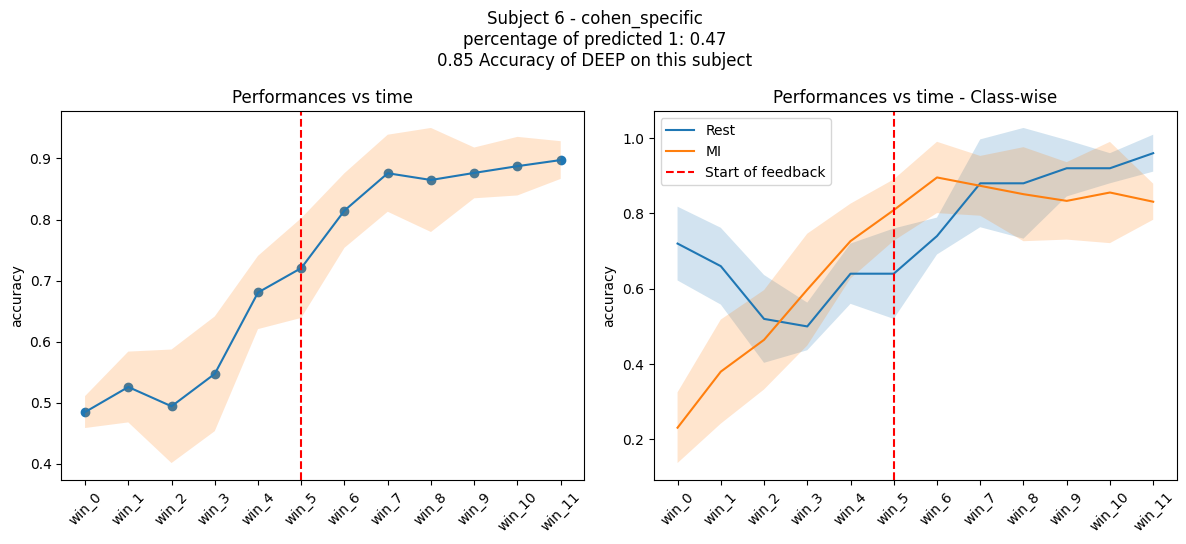

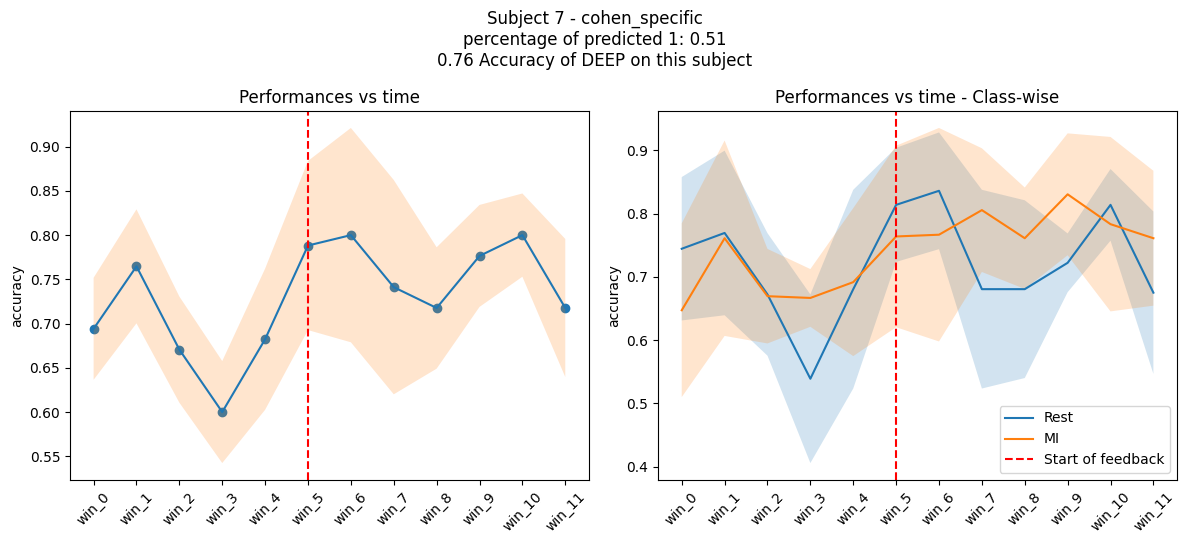

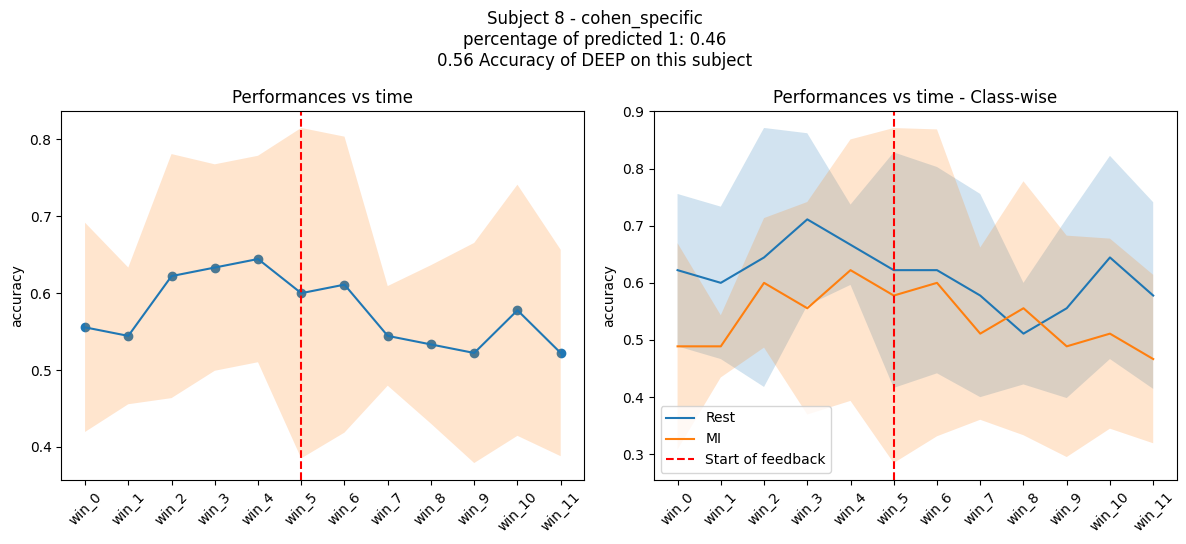

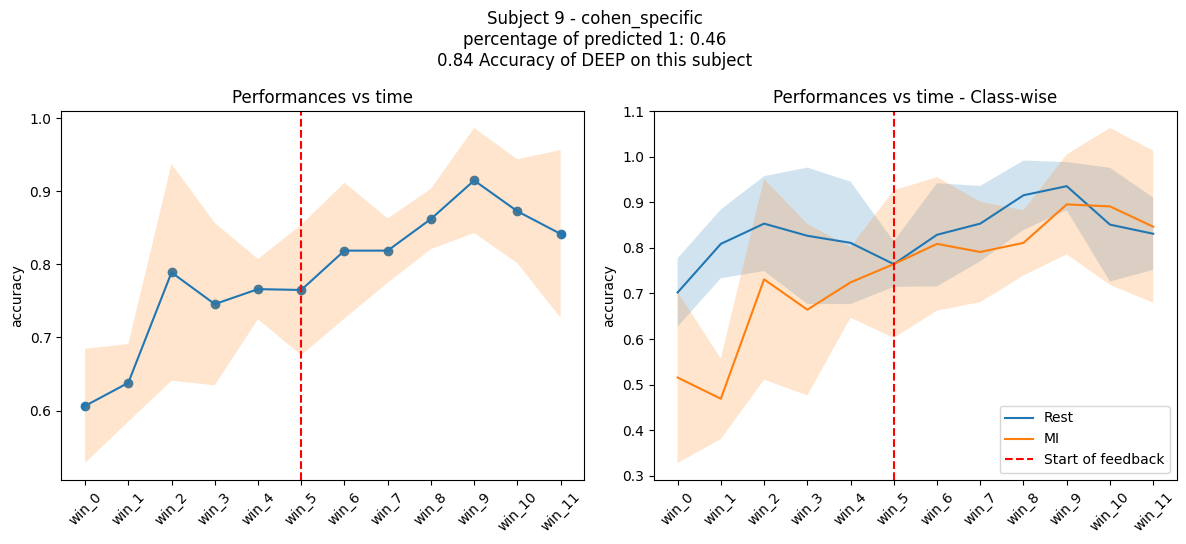

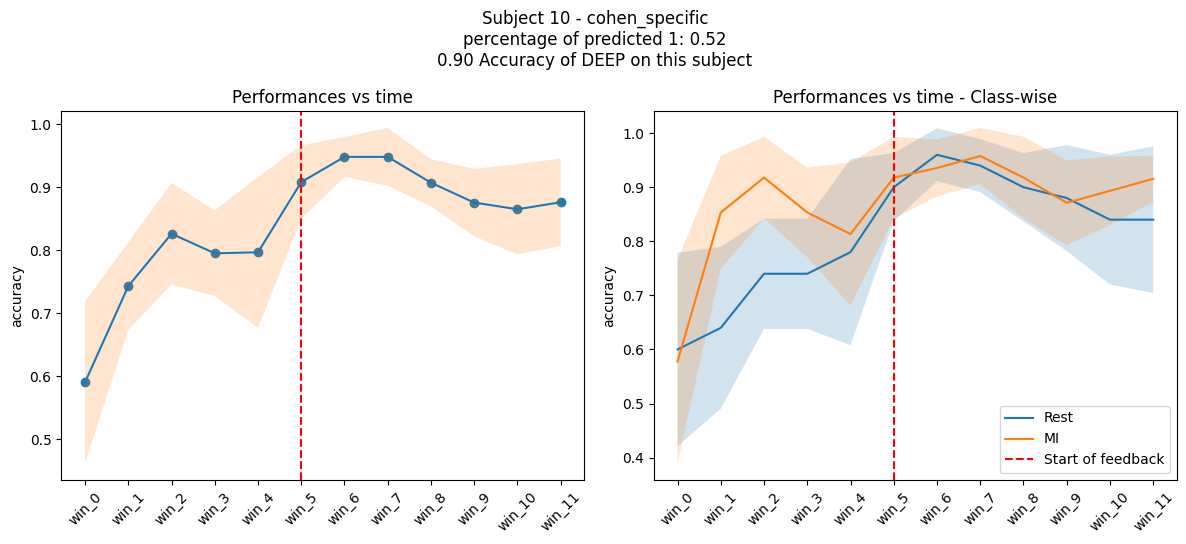

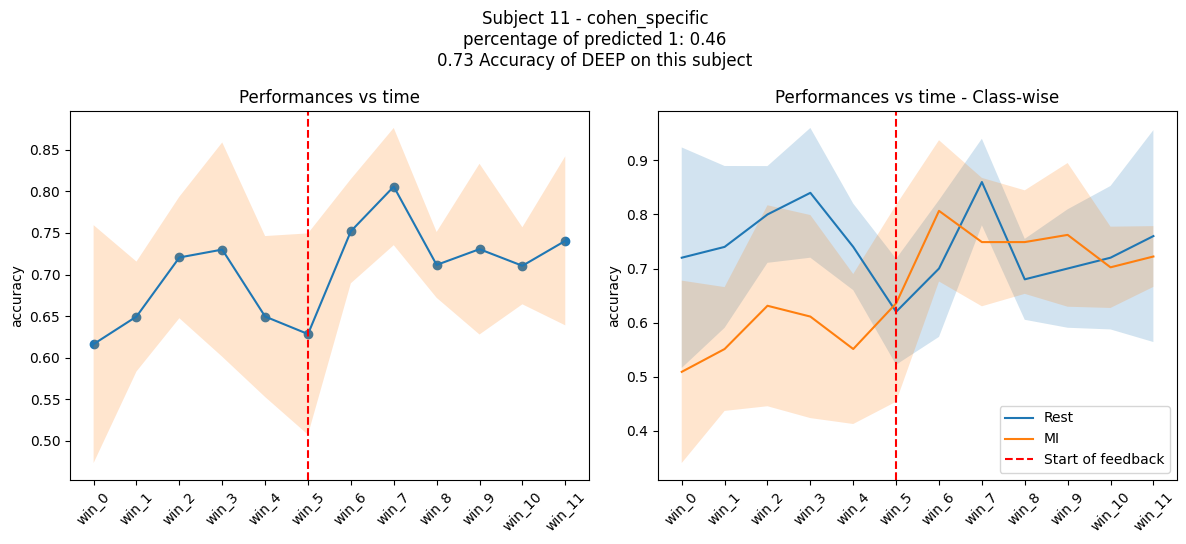

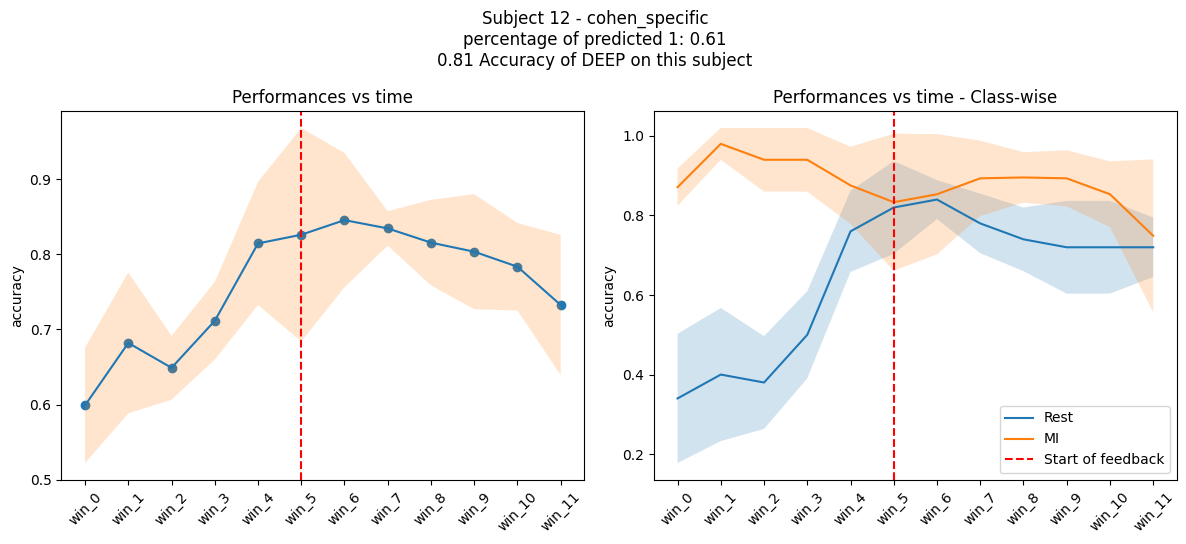

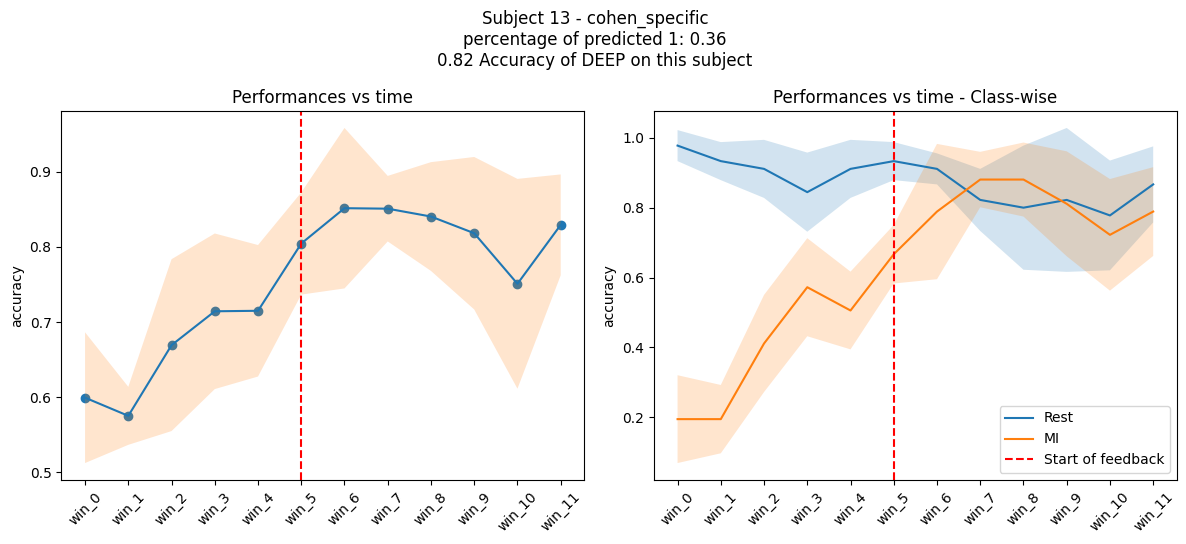

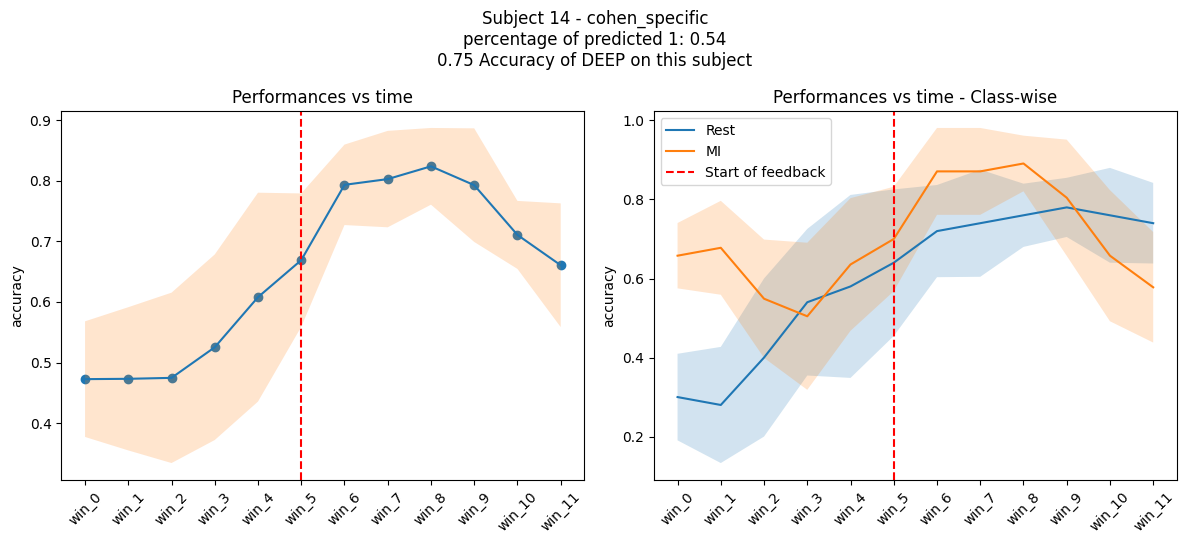

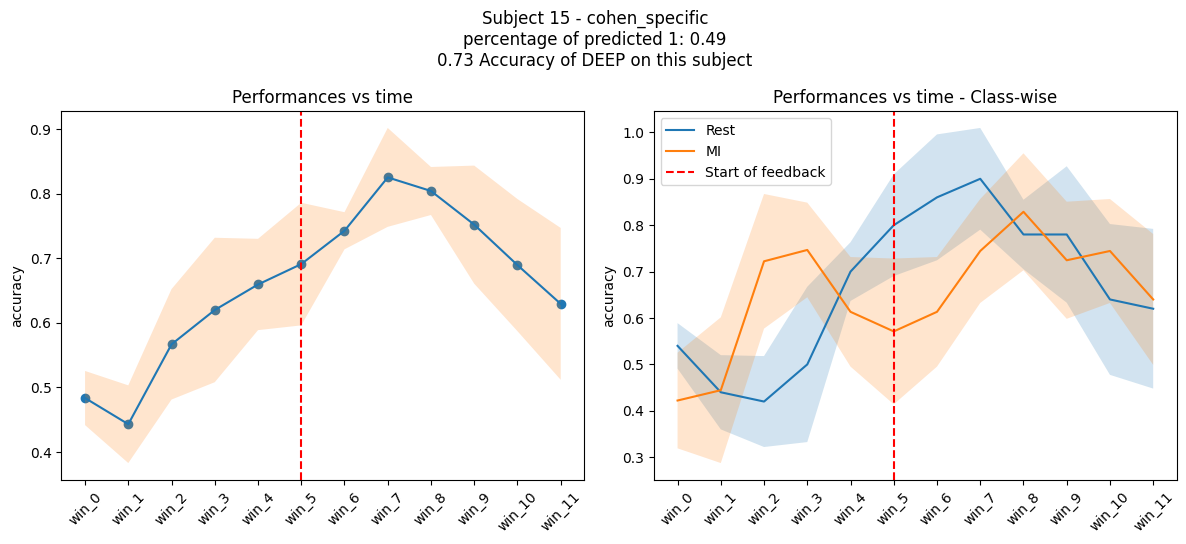

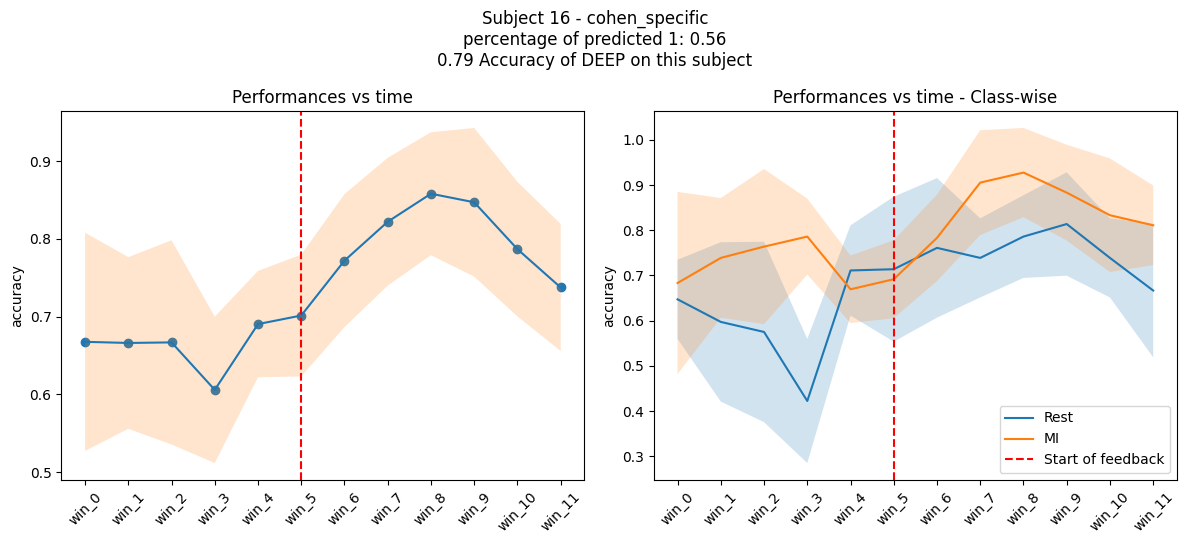

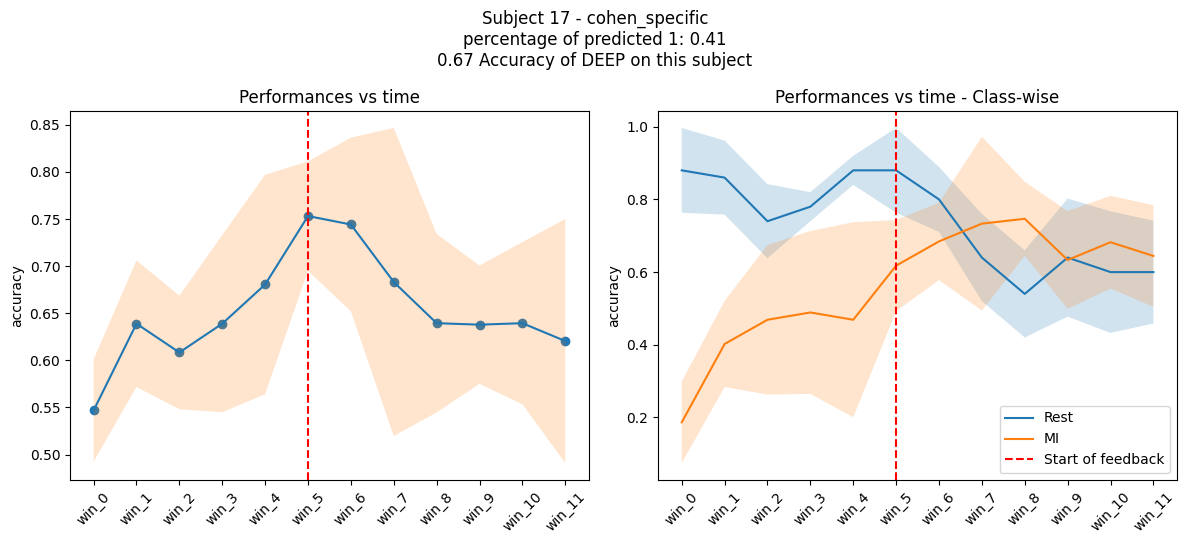

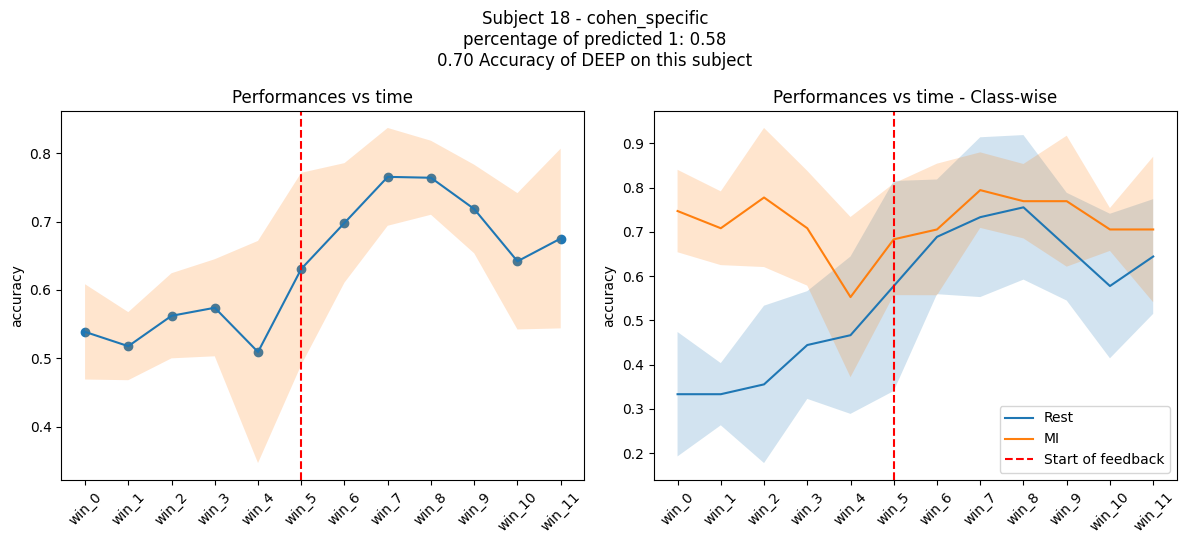

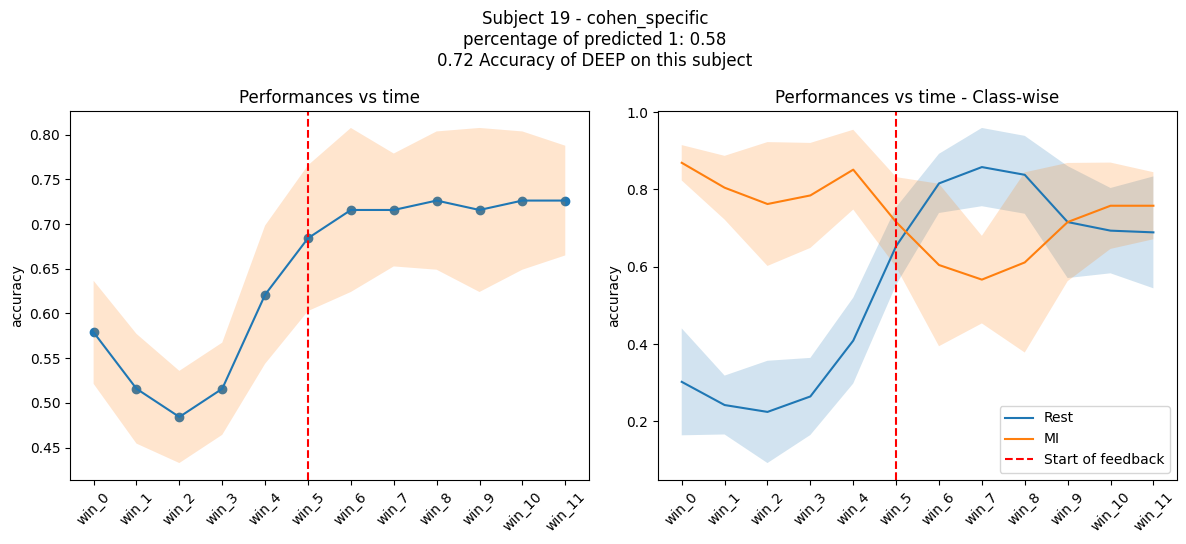

In [62]:
import pandas as pd

for subject_index in range(20):
    subject_result_across_time = pd.read_pickle(f"../Results/BCI_Performances/DNN/Across_time/Performances_DNN_across_time_subject_{subject_index}.pkl",)
    fold_accuracies = subject_result_across_time["fold_accuracies"]
    all_predictions = subject_result_across_time["all_predictions"]
    Details = subject_result_across_time["Details"]
    Selected_regions_per_fold_EEG_U_MEG = subject_result_across_time["Selected_regions_per_fold_EEG_U_MEG"]

    num_windows =len(fold_accuracies[0])


    # BALANCING of PREDICTIONs
    quanta_perc_1_per_fold = []
    for fold in range(5):
        somma = 0
        den = 0
        for win_dow in range(num_windows): 
            somma += all_predictions[fold][f"win_{win_dow}"]["y_pred"].sum()
            den += len(all_predictions[fold][f"win_{win_dow}"]["y_pred"])
        quanta_perc_1_per_fold.append(somma/den)
    quanta_perc_1_per_fold


    # PLOTS (per time)
    conteggio = 0; somma = 0
    accuracy_per_time = {}
    accuracy_per_fold = {}
    for key in fold_accuracies[0]:
        accuracy_per_time[key] = 0
    for _ in range(len(fold_accuracies)):
        for key in fold_accuracies[_]:
            conteggio += 1
            somma += fold_accuracies[_][key]
            accuracy_per_time[key]+= fold_accuracies[_][key]/5
            accuracy_per_fold[_] =  sum(list(fold_accuracies[_].values())[-7:]) / 7



    import numpy as np
    import matplotlib.pyplot as plt

    tag = "cohen_specific"


    # ---------- PRECOMPUTE COMMON AXIS ----------
    winds = sorted(all_predictions[0], key=lambda w: int(w.split("_")[1]))
    x = np.arange(len(winds))

    # ---------- CLASS-WISE ACCURACY (LEFT PANEL) ----------
    m0, s0, m1, s1 = [], [], [], []

    for w in winds:
        a0, a1 = [], []
        for fold in all_predictions:
            y = np.array(fold[w]["y_true"])
            p = np.array(fold[w]["y_pred"])
            a0.append((p[y == 0] == 0).mean())
            a1.append((p[y == 1] == 1).mean())
        m0.append(np.mean(a0)); s0.append(np.std(a0))
        m1.append(np.mean(a1)); s1.append(np.std(a1))

    m0, s0, m1, s1 = map(np.array, (m0, s0, m1, s1))

    # ---------- GLOBAL ACCURACY (RIGHT PANEL) ----------
    times = list(fold_accuracies[0])
    vals = np.array([[fold[t] for t in times] for fold in fold_accuracies])
    m, s = vals.mean(0), vals.std(0)

    # ---------- PLOTTING ----------
    fig, axs = plt.subplots(1, 2, figsize=(12, 5.5))

    # RIGHT
    ax = axs[1]
    ax.plot(x, m0, label="Rest")
    ax.fill_between(x, m0 - s0, m0 + s0, alpha=.2)

    ax.plot(x, m1, label="MI")
    ax.fill_between(x, m1 - s1, m1 + s1, alpha=.2)

    ax.set_title(f"Performances vs time - Class-wise")
    ax.set_xticks(x)
    ax.set_xticklabels(winds, rotation=45)
    ax.set_ylabel("accuracy")
    ax.legend()

    ymin, ymax = ax.get_ylim()
    ax.vlines(5, ymin, ymax, linestyles="dashed", colors="red", label="Start of feedback")
    ax.set_ylim(ymin, ymax)

    # LEFT
    ax = axs[0]

    ax.set_ylabel("accuracy")

    ax.plot(times, m)
    ax.scatter(times, list(accuracy_per_time.values()))
    ax.fill_between(times, m - s, m + s, alpha=.2)

    ax.set_xticks(x)
    ax.set_xticklabels(winds, rotation=45)
    ax.set_title(f"Performances vs time")

    ymin, ymax = ax.get_ylim()
    ax.vlines(5, ymin, ymax, linestyles="dashed", colors="red", label="Start of feedback")
    ax.set_ylim(ymin, ymax)
    plt.legend()
    plt.suptitle(f"Subject {subject_index} - {tag}\npercentage of predicted 1: {np.mean(quanta_perc_1_per_fold):.2f}\n"+
                 f"{np.mean(list(accuracy_per_fold.values())):.2f} Accuracy of DEEP on this subject")
    plt.tight_layout()
    plt.savefig(f"../_Deep_Learning/Images/Performance_across_time/Perf_vs_Time_sbj{subject_index}_{tag}_test_start_from_1sec_train_from_3sec")




np.float64(0.8120300751879699)

In [58]:
np.mean(quanta_perc_1_per_fold)

np.float64(0.5456140350877192)